In [4]:
import os
from pathlib import Path

# Jupyter runs from the notebooks/ folder — step up to repo root so paths work
os.chdir(Path.cwd().parent)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/lenny/ATML_Sepsis_Alert


# MIMIC-IV EDA — SepsisAlert
Quick exploratory analysis of the key tables.

In [5]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

ICU  = 'physionet.org/files/mimiciv/3.1/icu'
HOSP = 'physionet.org/files/mimiciv/3.1/hosp'

con = duckdb.connect()

## 1. ICU Stays overview

In [6]:
icu_stays = con.execute(f"""
    SELECT first_careunit, COUNT(*) as n_stays, AVG(los) as avg_los_days
    FROM read_csv_auto('{ICU}/icustays.csv.gz')
    GROUP BY first_careunit
    ORDER BY n_stays DESC
""").df()
icu_stays

,first_careunit,n_stays,avg_los_days
0,Medical Intensive Care Unit (MICU),20703,3.758191
1,Medical/Surgical Intensive Care Unit (MICU/SICU),15449,3.091032
2,Cardiac Vascular Intensive Care Unit (CVICU),14771,3.317241
3,Surgical Intensive Care Unit (SICU),13009,3.901684
4,Coronary Care Unit (CCU),10775,3.094193
5,Trauma SICU (TSICU),10474,3.642700
6,Neuro Intermediate,5776,5.021332
7,Neuro Surgical Intensive Care Unit (Neuro SICU),1751,4.480323
8,Neuro Stepdown,1421,4.065212
9,Surgery/Vascular/Intermediate,145,15.705265


## 2. Sepsis prevalence (ICD-10 A41.x)

In [7]:
sepsis = con.execute(f"""
    SELECT
        COUNT(DISTINCT hadm_id) as total_admissions,
        COUNT(DISTINCT CASE WHEN icd_code LIKE 'A41%' OR icd_code LIKE 'R652%' THEN hadm_id END) as sepsis_admissions
    FROM read_csv_auto('{HOSP}/diagnoses_icd.csv.gz')
    WHERE icd_version = 10
""").df()
sepsis['prevalence'] = sepsis['sepsis_admissions'] / sepsis['total_admissions']
sepsis

,total_admissions,sepsis_admissions,prevalence
0,254377,13431,0.0528


## 3. Sample key lab values (first 1000 rows of lactate)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

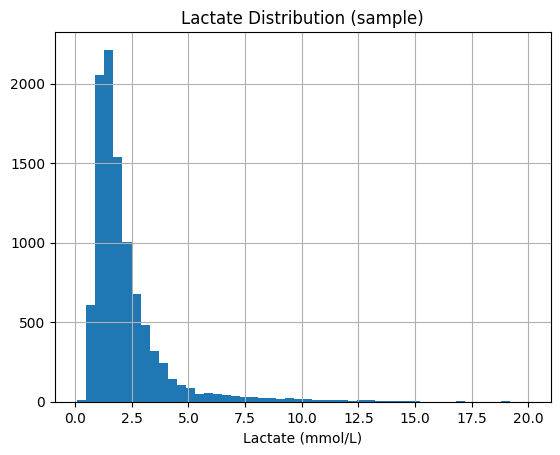

In [8]:
# itemid 50813 = Lactate
lactate = con.execute(f"""
    SELECT valuenum
    FROM read_csv_auto('{HOSP}/labevents.csv.gz')
    WHERE itemid = 50813
      AND valuenum IS NOT NULL
      AND valuenum BETWEEN 0 AND 20
    LIMIT 10000
""").df()

lactate['valuenum'].hist(bins=50)
plt.xlabel('Lactate (mmol/L)')
plt.title('Lactate Distribution (sample)')
plt.show()

## 4. Vital signs sample (Heart Rate)

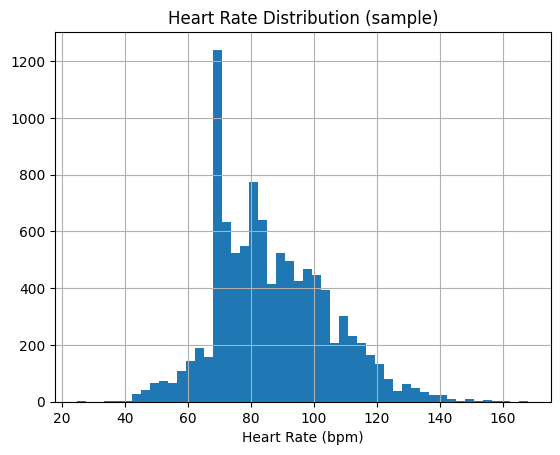

In [9]:
# itemid 220045 = Heart Rate
hr = con.execute(f"""
    SELECT valuenum
    FROM read_csv_auto('{ICU}/chartevents.csv.gz')
    WHERE itemid = 220045
      AND valuenum IS NOT NULL
      AND valuenum BETWEEN 20 AND 250
    LIMIT 10000
""").df()

hr['valuenum'].hist(bins=50)
plt.xlabel('Heart Rate (bpm)')
plt.title('Heart Rate Distribution (sample)')
plt.show()